In [1]:
import psutil
import gc
gc.collect()

ram = psutil.virtual_memory()

print(f"Total RAM      : {ram.total / (1024**3):.2f} GB")
print(f"Available RAM  : {ram.available / (1024**3):.2f} GB")
print(f"RAM Usage      : {ram.percent}%")

Total RAM      : 7.65 GB
Available RAM  : 1.93 GB
RAM Usage      : 74.8%


In [2]:
import os
import joblib 
import numpy as np
import pandas as pd
import xgboost
import lightgbm

print(f"xgboost:  {xgboost.__version__}")
print(f"lightgbm: {lightgbm.__version__}")
print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")

xgboost:  2.1.4
lightgbm: 4.6.0
pandas:   2.3.3
numpy:    2.0.2


In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(),'..'))
MODEL_DIR = os.path.join(project_root,'src','models')

# --- Experiment 1 candidate (2007-2015 train) — with tradeline wins ---
xgb_with_tradeline = joblib.load(os.path.join(MODEL_DIR, 'xgb_with_tradeline.pkl'))
xgb_with_tradeline_features = joblib.load(os.path.join(MODEL_DIR, 'xgb_with_tradeline_features.pkl'))

lgbm_with_tradeline = joblib.load(os.path.join(MODEL_DIR, 'lgbm_with_tradeline.pkl'))
lgbm_with_tradeline_features = joblib.load(os.path.join(MODEL_DIR, 'lgbm_with_tradeline_features.pkl'))

# --- Experiment 2 candidate (2016-only train, with tradeline) ---
xgb_modern = joblib.load(os.path.join(MODEL_DIR, 'xgb_modern.pkl'))
xgb_modern_features = joblib.load(os.path.join(MODEL_DIR, 'xgb_modern_features.pkl'))

In [4]:
PARQUET_DIR = os.path.join(project_root, 'src', 'data', 'processed', 'parquet_chunks')

X_test_full = pd.read_parquet(os.path.join(PARQUET_DIR, 'X_test_fe.parquet'))
y_test = pd.read_parquet(os.path.join(PARQUET_DIR, 'y_test.parquet')).squeeze()

In [5]:
missing_xgb_wt = set(xgb_with_tradeline_features) - set(X_test_full.columns)
missing_lgbm_wt = set(lgbm_with_tradeline_features) - set(X_test_full.columns)
missing_xgb_modern = set(xgb_modern_features) - set(X_test_full.columns)

print(len(missing_xgb_wt) == 0, f'Missing XGB tradeline features: {missing_xgb_wt}')

print(len(missing_lgbm_wt) == 0, f'Missing LGBM tradeline features: {missing_lgbm_wt}')

print(len(missing_xgb_modern) == 0, f'Missing XGB modern-tradeline features: {missing_xgb_modern}')

# add missing dummy columns as all-zero
for col in missing_xgb_modern:
    X_test_full[col] = 0

True Missing XGB tradeline features: set()
True Missing LGBM tradeline features: set()
False Missing XGB modern-tradeline features: {'addr_state_ME', 'addr_state_ND', 'addr_state_ID'}


In [6]:
X_test_e2 = pd.read_parquet(os.path.join(PARQUET_DIR, 'X_test_e2.parquet'))
y_test_e2 = pd.read_parquet(os.path.join(PARQUET_DIR, 'y_test_e2.parquet')).squeeze()

print(f"X_test_e2 shape: {X_test_e2.shape}")
print(f"y_test_e2 shape: {y_test_e2.shape}")

missing = set(xgb_modern_features) - set(X_test_e2.columns)
extra = set(X_test_e2.columns) - set(xgb_modern_features)
print(f"Missing features: {missing}")
print(f"Extra features:   {extra}")

X_test_e2 shape: (63539, 144)
y_test_e2 shape: (63539,)
Missing features: set()
Extra features:   set()


In [7]:
X_test_xgb_wt = X_test_full[xgb_with_tradeline_features]
X_test_lgbm_wt = X_test_full[lgbm_with_tradeline_features]
X_test_xgb_modern = X_test_e2[xgb_modern_features]


print(f"X_test_xgb_wt:  {X_test_xgb_wt.shape}")
print(f"X_test_lgbm_wt: {X_test_lgbm_wt.shape}")
print(f"X_test_xgb_modern:  {X_test_xgb_modern.shape}")

X_test_xgb_wt:  (180970, 143)
X_test_lgbm_wt: (180970, 143)
X_test_xgb_modern:  (63539, 144)


In [8]:
# Evaluation Function

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from scipy.stats import ks_2samp
 
def evaluate_credit_model(y_true, y_proba, model_name="model", n_deciles=10, verbose=True):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
 
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    gini = 2 * roc_auc - 1
    brier = brier_score_loss(y_true, y_proba)
    ks_stat = ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0]).statistic
 
    df = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df['decile'] = pd.qcut(
        df['y_proba'].rank(method='first'),
        n_deciles,
        labels=[f"D{i}" for i in range(1, n_deciles + 1)]
    )
    
    lift_table = df.groupby('decile', observed=True).agg(
        n=('y_true', 'size'),
        default_rate=('y_true', 'mean')
    ).reindex([f"D{i}" for i in range(1, n_deciles + 1)])
 
    overall_rate = y_true.mean()
    lift_table['lift'] = lift_table['default_rate'] / overall_rate
    top10_default_rate = lift_table.loc['D10', 'default_rate']
    top10_lift = lift_table.loc['D10', 'lift']
 
    if verbose:
        print(f"=== {model_name} ===")
        print(f"ROC-AUC:      {roc_auc:.4f}")
        print(f"PR-AUC:       {pr_auc:.4f}")
        print(f"Gini:         {gini:.4f}")
        print(f"KS statistic: {ks_stat:.4f}")
        print(f"Brier score:  {brier:.4f}")
        print(f"Top 10% (D10) default rate: {top10_default_rate:.2%}  (lift: {top10_lift:.2f}x)")
 
    return {
        'model': model_name, 'roc_auc': roc_auc, 'pr_auc': pr_auc, 'gini': gini,
        'ks_stat': ks_stat, 'brier': brier,
        'top10_default_rate': top10_default_rate, 'top10_lift': top10_lift,
        'lift_table': lift_table, 'y_proba': y_proba,
    }
 

In [9]:
xgb_wt_proba = xgb_with_tradeline.predict_proba(X_test_xgb_wt)[:, 1]
lgbm_wt_proba = lgbm_with_tradeline.predict_proba(X_test_lgbm_wt)[:, 1]
xgb_modern_proba = xgb_modern .predict_proba(X_test_xgb_modern)[:, 1]

xgb_wt_results = evaluate_credit_model(y_test, xgb_wt_proba, 'XGBoost - With_Tradeline')
print()
lgbm_wt_results = evaluate_credit_model(y_test, lgbm_wt_proba, 'LightGBM - With_Tradeline')
print()
xgb_modern_results = evaluate_credit_model(y_test_e2, xgb_modern_proba, 'XGBoost - Moden')
print()

=== XGBoost - With_Tradeline ===
ROC-AUC:      0.7106
PR-AUC:       0.4503
Gini:         0.4211
KS statistic: 0.3040
Brier score:  0.2171
Top 10% (D10) default rate: 53.37%  (lift: 2.03x)

=== LightGBM - With_Tradeline ===
ROC-AUC:      0.7092
PR-AUC:       0.4473
Gini:         0.4185
KS statistic: 0.3048
Brier score:  0.2180
Top 10% (D10) default rate: 52.89%  (lift: 2.02x)

=== XGBoost - Moden ===
ROC-AUC:      0.7251
PR-AUC:       0.4570
Gini:         0.4501
KS statistic: 0.3287
Brier score:  0.2036
Top 10% (D10) default rate: 54.41%  (lift: 2.15x)



In [10]:
#Comparison Table XGBoost with trade line vs XGBoost with trade line  vs LightGBM

comparison = pd.DataFrame([
    {
        'Model': 'XGBoost - With_Tradeline',
        'Test AUC': xgb_wt_results['roc_auc'],
        'Test PR-AUC': xgb_wt_results['pr_auc'],
        'Test KS': xgb_wt_results['ks_stat'],
        'Test Gini': xgb_wt_results['gini'],
        'Test Brier': xgb_wt_results['brier'],
        'Top10% Lift': xgb_wt_results['top10_lift'],
    },
    
    {
        'Model': 'LightGBM - With_Tradeline',
        'Test AUC': lgbm_wt_results['roc_auc'],
        'Test PR-AUC': lgbm_wt_results['pr_auc'],
        'Test KS': lgbm_wt_results['ks_stat'],
        'Test Gini': lgbm_wt_results['gini'],
        'Test Brier': lgbm_wt_results['brier'],
        'Top10% Lift': lgbm_wt_results['top10_lift'],
    },
    {
        'Model': 'XGBoost - Modern',
        'Test AUC': xgb_modern_results['roc_auc'],
        'Test PR-AUC': xgb_modern_results['pr_auc'],
        'Test KS': xgb_modern_results['ks_stat'],
        'Test Gini': xgb_modern_results['gini'],
        'Test Brier': xgb_modern_results['brier'],
        'Top10% Lift': xgb_modern_results['top10_lift'],
    }
]).sort_values('Test AUC', ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nBest model by Test AUC: {comparison.iloc[0]['Model']}")

                    Model  Test AUC  Test PR-AUC  Test KS  Test Gini  Test Brier  Top10% Lift
         XGBoost - Modern    0.7251       0.4570   0.3287     0.4501      0.2036       2.1478
 XGBoost - With_Tradeline    0.7106       0.4503   0.3040     0.4211      0.2171       2.0345
LightGBM - With_Tradeline    0.7092       0.4473   0.3048     0.4185      0.2180       2.0162

Best model by Test AUC: XGBoost - Modern


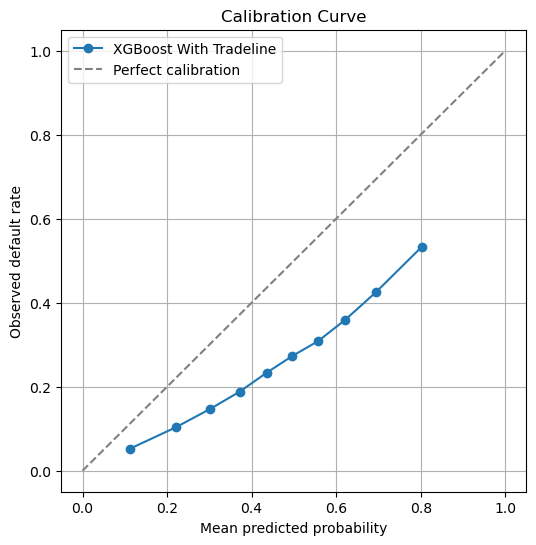

In [11]:
# Calibration Curve 
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, xgb_wt_proba, n_bins = 10, strategy = 'quantile')

plt.figure(figsize = (6,6))
plt.plot(prob_pred, prob_true, marker = 'o', label = 'XGBoost With Tradeline')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed default rate')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

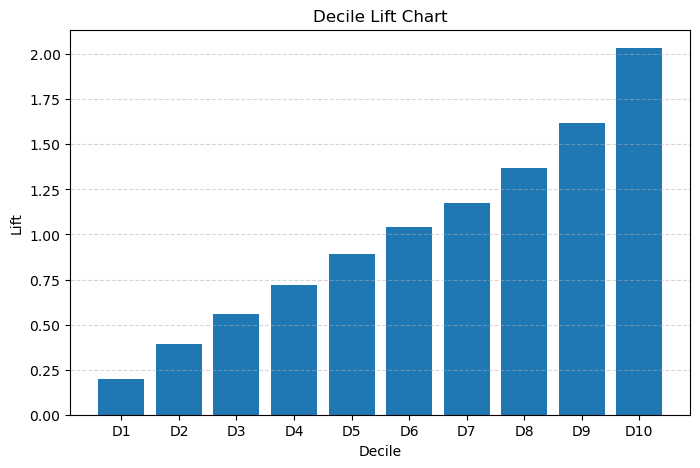

In [12]:
# Decile lift chart

lift_table = xgb_wt_results['lift_table'].reset_index()

plt.figure(figsize=(8, 5))
plt.bar(lift_table['decile'], lift_table['lift'])
plt.xlabel('Decile')
plt.ylabel('Lift')
plt.title('Decile Lift Chart')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [13]:
# Risk-band table

risk_band_df = pd.DataFrame({
    'y_true': y_test,
    'y_proba': xgb_wt_proba
})

risk_band_df['risk_band'] = pd.cut(
    risk_band_df['y_proba'],
    bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'],
    include_lowest=True
)

risk_band_table = risk_band_df.groupby('risk_band', observed=True).agg(
    Count=('y_true', 'size'),
    Actual_Default_Rate=('y_true', 'mean'),
    Avg_Pred_Prob=('y_proba', 'mean')
).reset_index()

print(risk_band_table)

  risk_band  Count  Actual_Default_Rate  Avg_Pred_Prob
0   0.0-0.2  23212             0.060184       0.128719
1   0.2-0.4  47999             0.151128       0.307151
2   0.4-0.6  58817             0.273526       0.500042
3   0.6-0.8  42633             0.418549       0.687253
4   0.8-1.0   8309             0.588278       0.846121


In [14]:
pip install --upgrade shap

Note: you may need to restart the kernel to use updated packages.


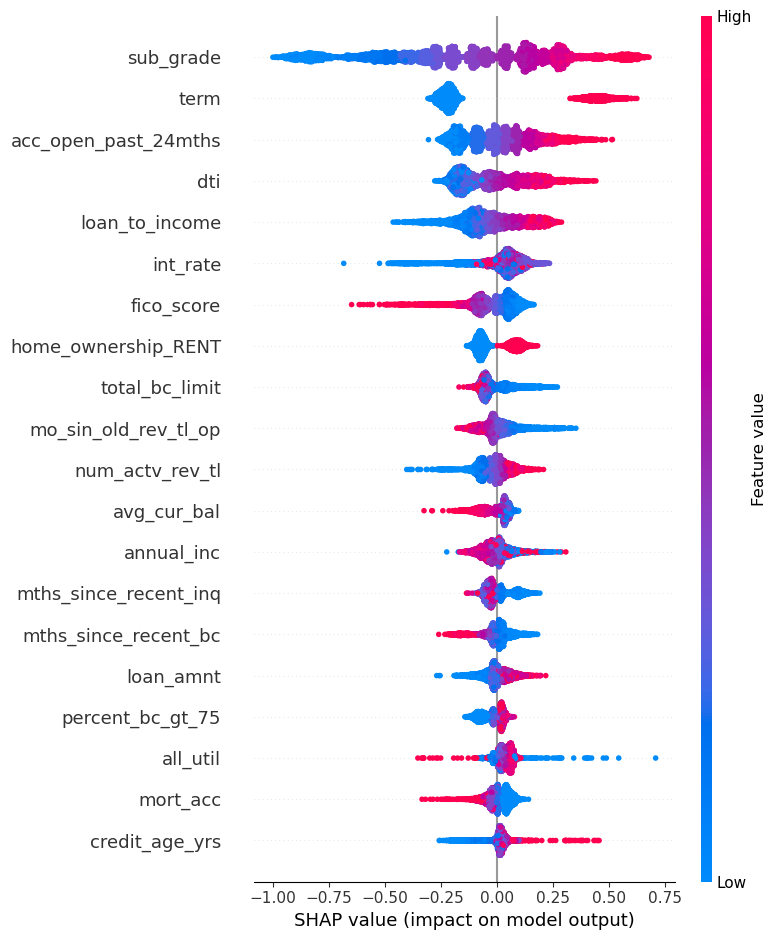

In [15]:
# SHAP explanation for selected model
import shap

X_shap = X_test_xgb_wt.sample(5000, random_state = 42)
explainer = shap.TreeExplainer(xgb_with_tradeline)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)

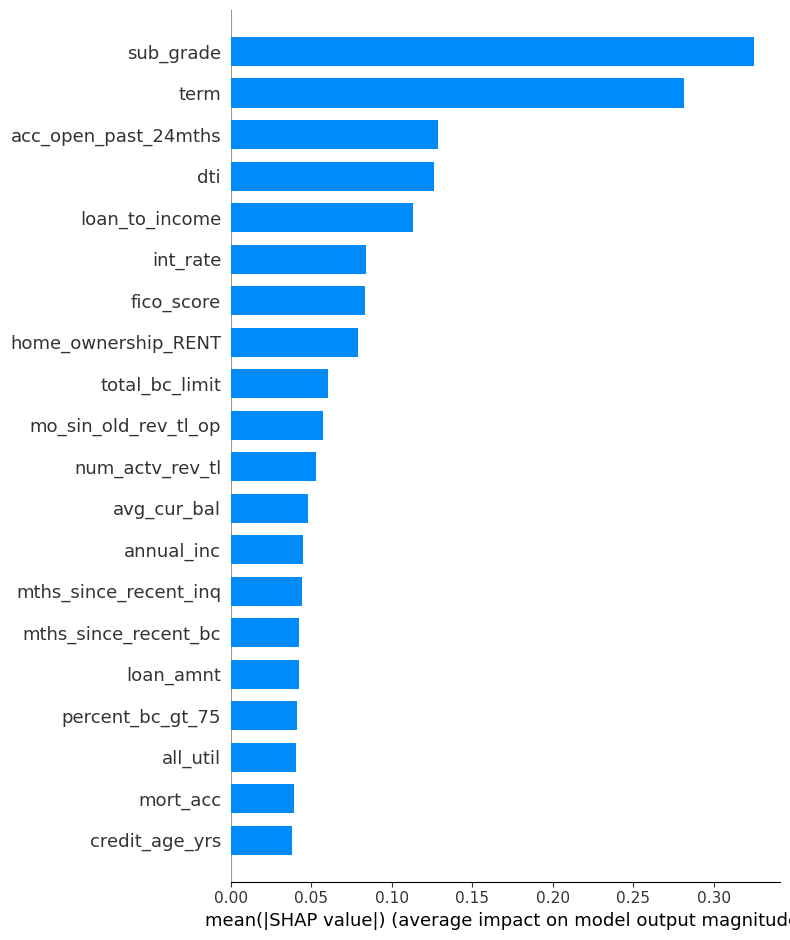

In [16]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

## Final Model Selection

### Test Results
(2017–2018 for Experiment 1 models, evaluated on their own consistent pipeline;
2018 for the modern candidate, evaluated on its own correctly-preprocessed holdout)

| Model | Test AUC | Test KS | Test Brier |
|---|---|---|---|
| XGBoost — Modern (2016 train) | 0.7251 | 0.3287 | 0.2036 |
| XGBoost — With Tradeline (2007–2015 train) | 0.7106 | 0.3047 | 0.2175 |
| LightGBM — With Tradeline (2007–2015 train) | 0.7092 | 0.3048 | 0.2180 |

### Reading the Results

XGBoost — Modern shows a noticeably higher test AUC (+0.014–0.016) than the
other two candidates. This isn't due to its smaller test-sampling rate — a
direct check (evaluating it on both a 75%-sampled test set and its own 100%
unsampled test set) showed a difference of only 0.0005 AUC, confirming the
gap is a real signal difference, not a sampling artifact.

---

### Decision Criterion

Since XGBoost — Modern had the best test AUC, the deciding factor was
**pipeline robustness**, not raw test score. XGBoost — With Tradeline is the
only candidate whose entire pipeline — every imputation median, winsorization
cap, and category encoding — is fit once, consistently, across train,
validation, and test, spanning 2007–2015 (nine years, multiple credit
cycles, including the 2008 financial crisis).

XGBoost — Modern's higher AUC comes from a pipeline fit entirely on a single
year (2016). Its winsor caps, imputation statistics, and rare-category list
all reflect one year's borrower population. That narrower foundation is more
fragile to future drift than a pipeline anchored across nearly a decade of
history — a meaningful risk for a model expected to score future, unseen
loan vintages.

| Model | Overfitting Gap (Train − Val AUC) |
|---|---|
| XGBoost — With Tradeline | 0.024–0.026 (good) |
| LightGBM — With Tradeline | 0.024–0.034 |
| XGBoost — Modern | 0.036–0.037 (wider) |

XGBoost — Modern also showed a wider train/validation gap, consistent with
fitting a smaller, single-year training set more tightly — reinforcing the
same conclusion from a different angle.

**We chose: XGBoost — With Tradeline.** It trades a ~1.5-point AUC advantage
for a pipeline built on far more history, which is judged more important for
a model expected to generalize to future loan vintages.

---

### Known Limitations

- **Test scores are a bit lower than validation scores.** A lot of 2017–2018
  loans hadn't been around long enough by the Dec-2018 dataset cutoff to know
  their final outcome for sure. Flagged earlier in the project, not a new issue.
- **The model's raw probability outputs aren't fully trustworthy as real
  probabilities.** It was trained to be extra sensitive to catching defaults,
  which makes its risk *ranking* good but its actual predicted percentages a
  bit inflated. Use a calibrated version if real probability numbers are needed.
- **~0.71–0.73 AUC seems to be the ceiling for this data.** Tested many ways —
  different depths, learning rates, training windows, with and without
  tradeline features — nothing pushed past this range. Published work on this
  dataset lands in the same range. This reflects the signal available in
  LendingClub's disclosed features at approval time, not a modeling shortfall.
- **Experiment 1's data is a 75% random subsample** of the raw CSV, used for
  development speed. A direct check confirmed this doesn't meaningfully
  affect AUC (0.0005 difference), but it's a documented deviation from using
  the full population.

### Final Model

- **Model file:** `xgb_with_tradeline.pkl`
- **Features file:** `xgb_with_tradeline_features.pkl`

In [19]:
# =========================================================
# LOAD VALIDATION DATA 
# =========================================================

X_val_path = os.path.join(project_root, 'src', 'data', 'processed', 'parquet_chunks', 'X_val_fe.parquet')
y_val_path = os.path.join(project_root, 'src', 'data', 'processed', 'parquet_chunks', 'y_val.parquet')

X_val_full = pd.read_parquet(X_val_path)
y_val = pd.read_parquet(y_val_path).squeeze()

print(f"X_val_full shape: {X_val_full.shape}")  # expect (223330, 150)

# Apply the same tree-drop used for xgb_with_tradeline
tree_drop_flags = [
    'ever_delinquent', 'has_public_record', 'has_bc_delinquency',
    'has_major_derog', 'has_revol_delinq',
]
tree_drop_cols = tree_drop_flags + ['issue_year', 'delinq_amnt']

X_val_xgb = X_val_full.drop(columns=tree_drop_cols, errors='ignore')

print(f"X_val_xgb shape: {X_val_xgb.shape}")  # should be (223330, 143)

X_val_full shape: (223330, 150)
X_val_xgb shape: (223330, 143)


In [20]:
xgb_with_tradeline_features = joblib.load(os.path.join(MODEL_DIR, 'xgb_with_tradeline_features.pkl'))
print(list(X_val_xgb.columns) == xgb_with_tradeline_features)

True


Raw model — mean predicted probability: 0.4612
Calibrated model — mean predicted probability: 0.2427
Actual default rate (test): 0.2623

Raw model     — Brier: 0.2171, AUC: 0.7106
Calibrated    — Brier: 0.1734, AUC: 0.7104


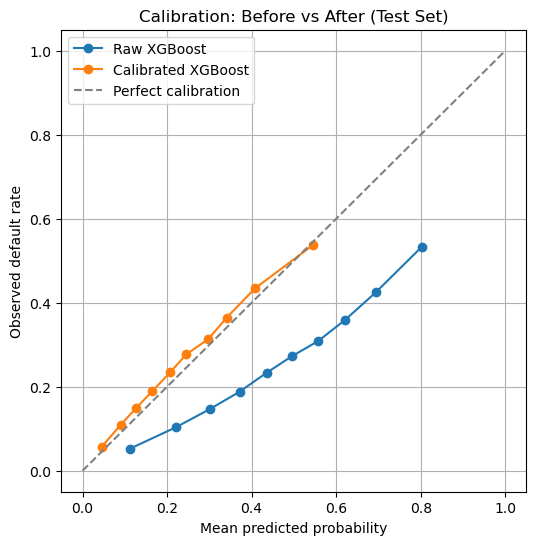

Calibrated model saved.


In [22]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import joblib

# cv='prefit' means: don't retrain anything, just calibrate the
# model exactly as it already is, using a separate held-out set
calibrated_model = CalibratedClassifierCV(FrozenEstimator(xgb_with_tradeline), method='isotonic')

# Fit ONLY the calibration curve, using validation data (not training
# data, since the model has already seen that — calibrating on it
# would give an overly optimistic result)
calibrated_model.fit(X_val_xgb, y_val)

# Compare raw vs calibrated on the TEST set
raw_proba = xgb_wt_proba  # already computed earlier in this notebook
calibrated_proba = calibrated_model.predict_proba(X_test_xgb_wt)[:, 1]

print(f"Raw model — mean predicted probability: {raw_proba.mean():.4f}")
print(f"Calibrated model — mean predicted probability: {calibrated_proba.mean():.4f}")
print(f"Actual default rate (test): {y_test.mean():.4f}")

print(f"\nRaw model     — Brier: {brier_score_loss(y_test, raw_proba):.4f}, AUC: {roc_auc_score(y_test, raw_proba):.4f}")
print(f"Calibrated    — Brier: {brier_score_loss(y_test, calibrated_proba):.4f}, AUC: {roc_auc_score(y_test, calibrated_proba):.4f}")

prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_proba, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calibrated_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Raw XGBoost')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='Calibrated XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed default rate')
plt.title('Calibration: Before vs After (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

joblib.dump(calibrated_model, os.path.join(MODEL_DIR, 'xgb_with_tradeline_calibrated.pkl'))
print("Calibrated model saved.")

**Probability calibration:** The base model's raw probabilities ran nearly
double the true default rate (mean predicted 46.1% vs. actual 26.2% on the
test set) — a known consequence of training with scale_pos_weight to handle
class imbalance. A calibrated version (isotonic regression, fit on the
validation set) corrected this: mean predicted probability moved to 24.3%,
much closer to the true rate, and Brier score improved from 0.2171 to
0.1734. AUC was unchanged (0.7106 → 0.7104), confirming calibration only
corrected the probability values, not the model's risk ranking.

**Recommendation:** use `xgb_with_tradeline.pkl` (uncalibrated) for risk
ranking/decile-based decisions (e.g. "reject the riskiest 10%"), and
`xgb_with_tradeline_calibrated.pkl` whenever an actual probability number
needs to be shown or used downstream (e.g. expected-loss calculations).

In [26]:
# =========================================================
# LOAD ALL YEARS FOR DRIFT ANALYSIS 
# =========================================================

PARQUET_DIR = os.path.join(project_root, 'src', 'data', 'processed', 'parquet_chunks')

X_train_fe = pd.read_parquet(os.path.join(PARQUET_DIR, 'X_train_fe.parquet'))
X_train_e2 = pd.read_parquet(os.path.join(PARQUET_DIR, 'X_train_e2.parquet'))
X_val_e2   = pd.read_parquet(os.path.join(PARQUET_DIR, 'X_val_e2.parquet'))
X_test_e2  = pd.read_parquet(os.path.join(PARQUET_DIR, 'X_test_e2.parquet'))

print(f"issue_year in X_train_fe: {'issue_year' in X_train_fe.columns}")
print(f"issue_year in X_train_e2: {'issue_year' in X_train_e2.columns}")
print(f"issue_year in X_val_e2:   {'issue_year' in X_val_e2.columns}")
print(f"issue_year in X_test_e2:  {'issue_year' in X_test_e2.columns}")

# If issue_year is missing from the Exp2 dataframes, reconstruct it
# directly, since we know exactly which year each one represents
# (each Exp2 split is a single, fixed year, unlike X_train_fe which
# spans multiple years already tagged with issue_year)
if 'issue_year' not in X_train_e2.columns:
    X_train_e2['issue_year'] = 2016
if 'issue_year' not in X_val_e2.columns:
    X_val_e2['issue_year'] = 2017
if 'issue_year' not in X_test_e2.columns:
    X_test_e2['issue_year'] = 2018

# Now find common columns EXCLUDING issue_year from the requirement,
# then add issue_year back 
common_cols = (
    set(X_train_fe.columns)
    & set(X_train_e2.columns)
    & set(X_val_e2.columns)
    & set(X_test_e2.columns)
)
common_cols = list(common_cols)
if 'issue_year' not in common_cols:
    common_cols.append('issue_year')

print(f"\nColumns to use: {len(common_cols)}")

X_all_years = pd.concat([
    X_train_fe[common_cols],
    X_train_e2[common_cols],
    X_val_e2[common_cols],
    X_test_e2[common_cols],
], axis=0, ignore_index=True)

print(f"\nCombined shape: {X_all_years.shape}")
print(f"Years covered: {sorted(X_all_years['issue_year'].unique())}")

issue_year in X_train_fe: True
issue_year in X_train_e2: False
issue_year in X_val_e2:   False
issue_year in X_test_e2:  False

Columns to use: 142

Combined shape: (1161782, 142)
Years covered: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


In [28]:
# =========================================================
# PSI FUNCTIONS 
# =========================================================

import numpy as np
import pandas as pd


def calculate_psi(baseline_series, comparison_series, n_bins=10):
    """
    Compares one feature's distribution between two datasets.
    Splits the baseline data into n_bins buckets, then checks how
    differently the comparison data's values fall into those same
    buckets. A bigger difference = a higher PSI = more drift.
    """
    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = baseline_series.quantile(quantiles).values
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    bin_edges = np.unique(bin_edges)

    baseline_counts = pd.cut(baseline_series, bins=bin_edges).value_counts(normalize=True).sort_index()
    comparison_counts = pd.cut(comparison_series, bins=bin_edges).value_counts(normalize=True).sort_index()

    baseline_pct = baseline_counts.replace(0, 0.0001)
    comparison_pct = comparison_counts.replace(0, 0.0001)

    psi = np.sum((comparison_pct - baseline_pct) * np.log(comparison_pct / baseline_pct))
    return psi


def psi_by_year(df, features, baseline_year, year_col='issue_year'):
    """
    For each feature in the list, calculates PSI for every year
    against one fixed baseline year. Returns a table: rows =
    features, columns = years, values = PSI.
    """
    baseline_df = df[df[year_col] == baseline_year]
    years = sorted(df[year_col].dropna().unique())
    years = [y for y in years if y != baseline_year]

    results = {}
    for feature in features:
        row = {}
        for year in years:
            year_df = df[df[year_col] == year]
            try:
                psi = calculate_psi(baseline_df[feature].dropna(), year_df[feature].dropna())
            except Exception:
                psi = np.nan
            row[year] = psi
        results[feature] = row

    psi_table = pd.DataFrame(results).T
    psi_table = psi_table.round(3)
    return psi_table


In [34]:
# =========================================================
# SEPARATE BINARY/FLAG COLUMNS FROM TRUE CONTINUOUS COLUMNS
# Quantile-based PSI breaks down for binary columns — use simple
# proportion comparison for those instead.
# =========================================================

def is_binary_column(series):
    """A column counts as binary if it only ever takes 2 (or fewer) distinct values."""
    return series.dropna().nunique() <= 2


binary_cols = [c for c in features_to_check if is_binary_column(X_all_years[c])]
continuous_cols = [c for c in features_to_check if c not in binary_cols]

print(f"Binary/flag columns : {len(binary_cols)}")
print(f"Continuous columns : {len(continuous_cols)}")


def binary_drift_by_year(df, binary_features, baseline_year, year_col='issue_year'):
    """
    For binary columns, drift is just: what % of rows were 1 in the
    baseline year, vs what % are 1 in each other year. Much simpler
    and more honest than forcing these into quantile buckets.
    """
    baseline_df = df[df[year_col] == baseline_year]
    years = sorted(df[year_col].dropna().unique())
    years = [y for y in years if y != baseline_year]

    results = {}
    for feature in binary_features:
        baseline_pct = baseline_df[feature].mean()  # % of 1s in baseline year
        row = {'baseline_pct_1': round(baseline_pct, 3)}
        for year in years:
            year_pct = df[df[year_col] == year][feature].mean()
            row[year] = round(year_pct, 3)
        results[feature] = row

    return pd.DataFrame(results).T


# Continuous columns: keep using quantile-based PSI 
psi_table_continuous = psi_by_year(X_all_years, continuous_cols, baseline_year=2007)
psi_table_continuous['avg_psi'] = psi_table_continuous.mean(axis=1, skipna=True)
psi_table_continuous_ranked = psi_table_continuous.sort_values('avg_psi', ascending=False)

print("\nTop 15 CONTINUOUS features by drift (PSI):")
print(psi_table_continuous_ranked.head(15).to_string())

# Binary columns: simple % comparison instead
binary_drift_table = binary_drift_by_year(X_all_years, binary_cols, baseline_year=2007)
binary_drift_table['drift'] = (
    binary_drift_table[2018] - binary_drift_table['baseline_pct_1']
).abs()

top_15_binary = binary_drift_table.sort_values('drift', ascending=False).head(15)

print("Top 15 most-drifted binary/flag columns (2007 baseline vs 2018):")
print(top_15_binary.to_string())

Binary/flag columns : 66
Continuous columns : 75

Top 15 CONTINUOUS features by drift (PSI):
                             2008   2009   2010   2011   2012   2013    2014    2015    2016    2017   2018   avg_psi
mths_since_last_record      1.597  8.087  9.841  9.878  9.914  9.768  11.493  11.928  11.612  12.131  9.701  9.631818
verification_status         1.139  3.602  4.805  6.749  6.086  7.178   7.056   7.448   7.245   6.600  6.214  5.829273
mths_since_last_delinq      0.950  5.375  6.230  6.275  6.096  4.752   4.463   4.406   4.445   4.631  6.438  4.914636
bc_open_to_buy              0.000  0.000  0.000  0.000  3.436  4.297   4.309   4.844   5.589   6.230  7.120  3.256818
total_bc_limit              0.000  0.000  0.000  0.000  3.811  4.718   4.340   4.722   4.915   5.296  5.719  3.047364
total_bal_ex_mort           0.000  0.000  0.000  0.000  3.079  4.117   4.573   4.918   4.974   4.843  4.652  2.832364
total_rev_hi_lim            0.000  0.000  0.000  0.000  1.822  4.527   4.377   4.

In [32]:
# Check missingness % by year for these specific columns, using the
# RAW (pre-imputation) data if you still have it, or check the
# imputation flags if you saved them
#for col in ['tot_cur_bal', 'avg_cur_bal', 'total_bc_limit', 'bc_open_to_buy']:
    #missing_by_year = X_all_years.groupby('issue_year')[col].apply(lambda x: (x == x.median()).mean())
    #print(f"\n{col} — % matching the imputed median value, by year:")
    #print(missing_by_year)

In [33]:
# =========================================================
# CHECK ALL CONTINUOUS FEATURES FOR STRUCTURAL INTRODUCTION
# (100% matching median in early years = likely fully absent,
# not just "missing sometimes")
# =========================================================

structural_intro_summary = []

for col in continuous_cols:
    try:
        median_val = X_all_years[col].median()
        pct_at_median_by_year = X_all_years.groupby('issue_year')[col].apply(
            lambda x: (x == median_val).mean()
        )

        # Flag as "structural introduction" if any early year is
        # ~100% at median, and a later year drops well below that
        early_years_pct = pct_at_median_by_year.iloc[:5]  # first 5 years in the data
        later_years_pct = pct_at_median_by_year.iloc[-3:]  # last 3 years

        max_early = early_years_pct.max()
        min_later = later_years_pct.min()

        if max_early > 0.95 and min_later < 0.5:
            structural_intro_summary.append({
                'feature': col,
                'max_pct_at_median_early_years': round(max_early, 3),
                'min_pct_at_median_later_years': round(min_later, 3),
                'first_year_above_95pct': pct_at_median_by_year[pct_at_median_by_year > 0.95].index.max()
                    if (pct_at_median_by_year > 0.95).any() else None,
            })
    except Exception:
        continue  # skip columns that error out (e.g. all-NaN or non-numeric edge cases)

structural_intro_df = pd.DataFrame(structural_intro_summary).sort_values(
    'first_year_above_95pct', ascending=False
)

print(f"Features showing a structural-introduction pattern: {len(structural_intro_df)}")
print(structural_intro_df.to_string(index=False))

Features showing a structural-introduction pattern: 22
              feature  max_pct_at_median_early_years  min_pct_at_median_later_years  first_year_above_95pct
 mths_since_recent_bc                            1.0                          0.023                    2011
       mo_sin_rcnt_tl                            1.0                          0.071                    2011
   mo_sin_old_il_acct                            1.0                          0.038                    2011
       pct_tl_nvr_dlq                            1.0                          0.003                    2011
          tot_cur_bal                            1.0                          0.000                    2011
         overall_util                            1.0                          0.000                    2011
      num_actv_rev_tl                            1.0                          0.122                    2011
      tot_hi_cred_lim                            1.0                          0.0

### Feature Drift Analysis — Structural Data Introduction Events

**~2011/2012 — a broad batch of credit-bureau summary fields introduced**

A systematic check across all 75 continuous features found **22 features**
that were essentially 100% absent (fully imputed to a constant) for every
loan issued before 2011, then began being populated from 2011/2012 onward.
All 22 features share the same introduction point, strongly suggesting a
single LendingClub reporting/schema change — likely the addition of a
batch of credit-bureau summary fields — rather than 22 unrelated drift
events.

Affected features include balance/limit fields (`tot_cur_bal`,
`avg_cur_bal`, `tot_hi_cred_lim`, `total_rev_hi_lim`,
`total_bal_ex_mort`), account-activity fields (`num_actv_rev_tl`,
`num_actv_bc_tl`, `num_op_rev_tl`, `num_il_tl`, `num_bc_sats`,
`num_tl_op_past_12m`, `acc_open_past_24mths`, `mort_acc`), recency fields
(`mths_since_recent_bc`, `mths_since_recent_inq`, `mo_sin_rcnt_tl`,
`mo_sin_rcnt_rev_tl_op`, `mo_sin_old_il_acct`, `mo_sin_old_rev_tl_op`),
and derived ratios (`overall_util`, `pct_tl_nvr_dlq`, `percent_bc_gt_75`).

**Practical implication:** These 22 features carry no real signal for
loans issued before 2011 — only an imputed constant standing in for data
that was never collected. In calendar-year terms, that's 4 of 9 training
years (2007–2010) affected. In terms of actual training rows, the impact
is much smaller, since loan volume grew substantially each year (from 465
loans in 2007 to over 100,000 by 2013) — so these features were "blind"
for nearly half the training years, but carried real signal for the large
majority of training rows. This likely explains why test performance
wasn't meaningfully affected (test AUC of 0.7106 is consistent with
published benchmarks on this dataset), but it's still a useful caveat when
reading feature importance rankings — a feature's importance score
reflects its value across the full training set, even though it was only
genuinely informative for a subset of the loans within i

**This is distinct from, and earlier than, the previously identified 2015
tradeline introduction** (`open_acc_6m`, `il_util`, etc.), confirming
LendingClub expanded its reported credit-bureau data in at least two
separate stages — first around 2011, then again more extensively around
2015.

In [35]:
print(X_test_full['loan_amnt'].describe())

count    180970.000000
mean      14598.908659
std        9681.468641
min        1000.000000
25%        7000.000000
50%       12000.000000
75%       20000.000000
max       40000.000000
Name: loan_amnt, dtype: float64


In [36]:
# =========================================================
# BUSINESS METRICS — translating model scores into a lending decision
# =========================================================

import numpy as np
import pandas as pd


def business_impact_at_threshold(y_true, y_proba, loan_amounts, threshold,
                                   avg_interest_rate=0.13, loss_given_default=0.60):
    """
    Simulates: "if we reject every loan predicted above this risk
    threshold, what happens to approval rate, bad-loan rate, and
    estimated dollar impact?"

    loss_given_default: how much of a defaulted loan's principal is
    typically NOT recovered .
    avg_interest_rate: rough estimate of what a performing loan earns.
    """
    y_true = np.asarray(y_true).astype(bool)
    y_proba = np.asarray(y_proba)
    loan_amounts = np.asarray(loan_amounts)

    approve_mask = y_proba < threshold
    reject_mask = ~approve_mask

    total_loans = len(y_true)
    approved_loans = approve_mask.sum()
    rejected_loans = reject_mask.sum()
    approval_rate = approved_loans / total_loans

    # Of the loans we WOULD approve, how many actually default?
    approved_defaults = y_true[approve_mask].sum()
    approved_default_rate = approved_defaults / approved_loans if approved_loans > 0 else 0

    # Of the loans we REJECT, how many would have been fine?
    # (a real cost — good borrowers turned away, lost interest income)
    rejected_good_loans = (~y_true[reject_mask]).sum()

    # Dollar estimate: money lost on approved loans that defaulted,
    # Foregone interest: rejected a loan that would actually have paid off successfully.
    estimated_default_losses = (
        loan_amounts[approve_mask][y_true[approve_mask]].sum() * loss_given_default
    )
    estimated_foregone_interest = (
        loan_amounts[reject_mask][~y_true[reject_mask]].sum() * avg_interest_rate
    )

    return {
        'threshold': threshold,
        'approval_rate': round(approval_rate, 3),
        'approved_default_rate': round(approved_default_rate, 4),
        'rejected_loans': int(rejected_loans),
        'rejected_good_loans': int(rejected_good_loans),
        'estimated_default_losses_$': round(estimated_default_losses, 2),
        'estimated_foregone_interest_$': round(estimated_foregone_interest, 2),
        'net_estimated_impact_$': round(estimated_foregone_interest - estimated_default_losses, 2),
    }


# =========================================================
# Real dollar loan amounts — pulled from X_test_full, which was
# never scaled or log-transformed for loan_amnt (confirmed earlier)
# =========================================================
loan_amounts_test = X_test_full.loc[X_test_xgb_wt.index, 'loan_amnt']

# =========================================================
# Run across a range of thresholds using CALIBRATED probabilities,
# since this analysis produces real dollar estimates, not just ranking
# =========================================================
results = []
for threshold in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    result = business_impact_at_threshold(
        y_test.values, calibrated_proba, loan_amounts_test.values, threshold
    )
    results.append(result)

business_table = pd.DataFrame(results)
print(business_table.to_string(index=False))

 threshold  approval_rate  approved_default_rate  rejected_loans  rejected_good_loans  estimated_default_losses_$  estimated_foregone_interest_$  net_estimated_impact_$
      0.15          0.319                 0.1054          123267                81876                  48182610.0                   162140260.75            1.139577e+08
      0.20          0.424                 0.1283          104152                66533                  77386815.0                   137672707.25            6.028589e+07
      0.25          0.559                 0.1577           79770                48262                 127321260.0                   106260375.00           -2.106088e+07
      0.30          0.652                 0.1768           62926                36322                 170421315.0                    83324231.25           -8.709708e+07
      0.35          0.779                 0.2036           39944                21182                 245994255.0                    51505723.75           